# Assignment 2: Text Classification

Goal:Train a text classification model to classify traffic sentiments from the free-floating text as either positive or negative based on an open dataset. 
- Identify which vectorization method works the best or basically does not much difference. 
- Identify which model, together with its corresponding hyperparameters, gives the best performance for traffic sentimental analysis.

 Workflow
 
                   DATA
                     ↓
              Remove duplicates
                     ↓
             Train/test split
                 80% / 20%
                     ↓
          ┌──────────┴──────────┐
          ↓                     ↓
    CountVectorizer        TF-IDF
          ↓                     ↓
       Hashing            compare them
          └──────────┬──────────┘
                     ↓
              Best vectorizer
                     ↓
       ┌─────────────┼─────────────┐
       ↓             ↓             ↓
      LR            KNN           RF
       ↓             ↓             ↓
      XGB           SVM          NB
       └─────────────┼─────────────┘
                     ↓
              Compare models
                     ↓
              Best model
                     ↓
              GridSearchCV
                     ↓
            Best parameters
                     ↓
         5-fold CV performance
                     ↓
             Final test result

### 1. Import libraries needed

In [1]:
# Pandas is used to work with tables/dataframes
import pandas as pd

# NumPy is useful for numerical calculations
import numpy as np

# Matplotlib is used for graphs
import matplotlib.pyplot as plt

# WordCloud creates a visualisation of the most common words
from wordcloud import WordCloud

# train_test_split separates our data into training and testing data
# GridSearchCV is used later to find the best model parameters
from sklearn.model_selection import train_test_split, GridSearchCV

# These are the three text vectorizers we will compare
from sklearn.feature_extraction.text import (
    CountVectorizer,
    HashingVectorizer,
    TfidfVectorizer
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB

# XGBoost classification model
from xgboost import XGBClassifier

# Metrics used to evaluate classification performance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

### 2. Load Dataset

In [2]:
# URL path of the Pakistani Traffic Sentiment Analysis dataset
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_4_Text_classification/Pakistani%20Traffic%20sentiment%20Analysis.csv'


# Load the data with pandas
df = pd.read_csv(url)

# Display the data
df.head()

# 0 is positive language while 1 is negative language 

,Text,Sentiment
0,Adayala road is clear,0
1,Traffic jam from parbat rd to nazim-ud-din rd ...,1
2,Mandra is clear,0
3,Fort street is clear,0
4,"Mashriq Hotel towards Fawara Chowk, City Sadda...",1


Understand what we are looking at

In [3]:
# Show the number of rows and columns
print("Dataset shape:", df.shape)

# Show the column names
print("\nColumns:")
print(df.columns)

# Show basic information about the dataframe
print("\nDataset information:")
df.info()

# Check how many observations belong to each sentiment class. Is it balanced?
df.groupby('Sentiment').describe()

Dataset shape: (2109, 2)

Columns:
Index(['Text', 'Sentiment'], dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2109 entries, 0 to 2108
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Text       2109 non-null   str  
 1   Sentiment  2109 non-null   int64
dtypes: int64(1), str(1)
memory usage: 33.1 KB


Text                                                               
          count unique                                                top freq
Sentiment                                                                     
0          1010   1008                   Traffic open at shahrah e faisal    2
1          1099   1079  Road is closed for traffic at star gate toward...    3

### 3. Clean data


In [4]:
# Delete the duplicate rows
df = df.drop_duplicates()

# Check the instances of each class
df.groupby('Sentiment').describe()

Text                                                               
          count unique                                                top freq
Sentiment                                                                     
0          1008   1008                              Adayala road is clear    1
1          1079   1079  Traffic jam from parbat rd to nazim-ud-din rd ...    1

### 4. Word cloud

Explanatory analysis: Display which words appear frequently by how big the word is

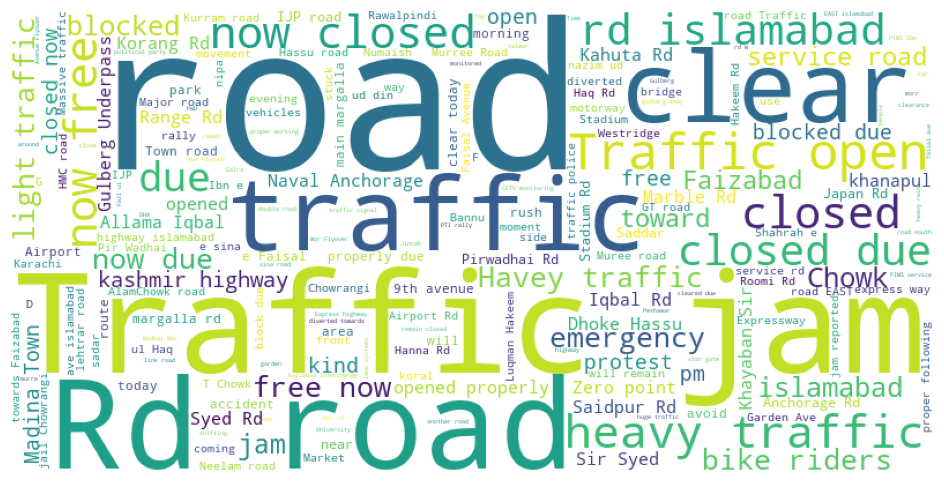

In [5]:
# Combine all text into one large string
text = " ".join(df['Text'].astype(str))

# Create the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### 5. Define X and Y

In [6]:
# X contains the information we use to make predictions
# Convert the text to vectorizer
X = df['Text'] # question

# y contains the answer we want the model to learn
# Obtain the label
# Here, that answer is positive (0) or negative (1)
y = df['Sentiment'] # answer

### 6. Split df into training and testing data

In [7]:
# Split the data into training and testing sets with the 80/20 rule

# random_state=0 ensures that we get the same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0 # not 42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 1669
Testing observations: 418


### 7. Text vectorization
Goal: Change words into numbers\
Objective: Test the three models: CountVectorizer, TF-IDF and HashingVectorizer

#### 7.1 CountVectorizer
Goal: converts words into numerical features\
Question: What words/phrases exist in my vocabulary?

In [41]:
# OG
# count_vectorizer = CountVectorizer(
#     ngram_range=(1, 2),   # # 1-word combinations (unigrams) and 2-word combinations (bigrams)
#     stop_words='english', # removes common words such as "the", "is", "and", etc.
#     min_df=20             # words appearing in fewer than 20 documents are ignored
# )

# wee tweeks
count_vectorizer = CountVectorizer(
    ngram_range=(1, 1),   # change to 1,1 - Results in higher accuracy, individual-word frequencies are more useful for this dataset than the additional bigrams
    stop_words='english', 
    min_df=20             
)

# -- document = one piece of text that we are analysing - i.e. one row of the Text column

# Learn the vocabulary from the training df AND transform the training text into numbers
X_train_count = count_vectorizer.fit_transform(X_train)

# Transform the test text using the vocabulary learned from training
X_test_count = count_vectorizer.transform(X_test)

print("Training matrix shape:", X_train_count.shape)
print("Testing matrix shape:", X_test_count.shape)


Training matrix shape: (1669, 93)
Testing matrix shape: (418, 93)


#### 7.2 TF-IDF
Goal: give different importance to words depending on how useful they are for distinguishing between documents 

In [42]:
# OG
# tfidf_vectorizer = TfidfVectorizer(
#     min_df=20,              # ignore words that appear in fewer than 20  different docs, helps reduce the number of useless features
#     norm='l2',              # standardise the size of each text's numerical representation. Purpose - making sure than longer comments do not dautomatically dominate simply bc it contains more words
#     smooth_idf=True,        # adjustment in the IDF calc so it behaves sensibly for words depending on thier doc envr
#     use_idf=True,           # use the IDF of TF-IDF, False = TF
#     ngram_range=(1, 1),     # number of words grouped together - i.e 1,1 only use ind words aka unigrams 
#     stop_words='english'
# )

# # wee tweeks
tfidf_vectorizer = TfidfVectorizer(
    min_df=20,              
    norm='l2',             
    smooth_idf=True,        
    use_idf=True,           
    ngram_range=(1, 2),      # change to 1,2 - Results in a higher accuracy. it allows to recognise phrase e.g. word 'traffic' is bad but in trafic jam (bad) while traffic is flowing smoothly (good)
    stop_words='english'
)

# Learn the vocabulary AND transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data using the vocabulary learned above
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (1669, 150)
Testing matrix shape: (418, 150)


#### 7.3 HashingVectorizer
Purpose: converts words into a fixed number of numerical features using a hashing function\
Does not need to lern the vocab first bc it uses the mathemtical hashing function directly so just transform not Fit_transformm

In [43]:
# OG
# hash_vectorizer = HashingVectorizer(
#     ngram_range=(1, 2),
#     n_features=200          # create 200 numerical feature columns i.e. compress all these words (1000+) into 200 numerical columns
# )

# wee tweeks
hash_vectorizer = HashingVectorizer(
    ngram_range=(1, 2),      # change to 1,1 higher accuracy than 1,2 
    n_features=1000          # change to 500, 1000 - Results: higher  n of features increases the accuracy i.e. more space to organize 
)

# Transform the training text
X_train_hash = hash_vectorizer.transform(X_train)

# Transform the test text
X_test_hash = hash_vectorizer.transform(X_test)

print("Training matrix shape:", X_train_hash.shape)
print("Testing matrix shape:", X_test_hash.shape)

Training matrix shape: (1669, 1000)
Testing matrix shape: (418, 1000)


### 8. Baseline model to fit the df - Logistic Regression

In [26]:
# Create a Logistic Regression classifier
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=0
)

# Train the model using the CountVectorizer data
logistic_model.fit(X_train_count, y_train)

# Predict the sentiment of the test texts
logistic_predictions = logistic_model.predict(X_test_count)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression accuracy:", logistic_accuracy)

Logistic Regression accuracy: 0.9401913875598086


### 9. Comparison of the three vectorizers methods
Question: which vectorization method works best?

In [44]:
# Create a dictionary to store the results
vectorizer_results = {}

# -----------------------------
# CountVectorizer
# -----------------------------

count_model = LogisticRegression(
    max_iter=1000,
    random_state=0
)

count_model.fit(X_train_count, y_train)

count_predictions = count_model.predict(X_test_count)

vectorizer_results['CountVectorizer'] = accuracy_score(
    y_test,
    count_predictions
)


# -----------------------------
# TF-IDF
# -----------------------------

tfidf_model = LogisticRegression(
    max_iter=1000,
    random_state=0
)

tfidf_model.fit(X_train_tfidf, y_train)

tfidf_predictions = tfidf_model.predict(X_test_tfidf)

vectorizer_results['TfidfVectorizer'] = accuracy_score(
    y_test,
    tfidf_predictions
)


# -----------------------------
# HashingVectorizer
# -----------------------------

hash_model = LogisticRegression(
    max_iter=1000,
    random_state=0
)

hash_model.fit(X_train_hash, y_train)

hash_predictions = hash_model.predict(X_test_hash)

vectorizer_results['HashingVectorizer'] = accuracy_score(
    y_test,
    hash_predictions
)


# Display the results
vectorizer_results

# 0.9401913875598086

{'CountVectorizer': 0.9401913875598086,
 'TfidfVectorizer': 0.9545454545454546,
 'HashingVectorizer': 0.9808612440191388}

Higher accuracy for hashingvectorizer.\
I tested different configurations and found that vectorization performance depends on the representation settings.

In [45]:
# Convert the results into a dataframe
vectorizer_results_df = pd.DataFrame(
    list(vectorizer_results.items()),
    columns=['Vectorizer', 'Accuracy']
)

# Sort from best to worst
vectorizer_results_df = vectorizer_results_df.sort_values(
    'Accuracy',
    ascending=False
)

vectorizer_results_df

,Vectorizer,Accuracy
2,HashingVectorizer,0.980861
1,TfidfVectorizer,0.954545
0,CountVectorizer,0.940191


#### 9.2 Chosen vectorizer - Hash

In [46]:
X_train_vectorized = X_train_hash
X_test_vectorized = X_test_hash

### 10. Text Classification Models

#### 10.1 Models

In [48]:
# Create the different classification models

models = {
    # LR
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=0
    ),

    # (2) KNN
    'KNN': KNeighborsClassifier(),

    # (3) RF
    'Random Forest': RandomForestClassifier(
        random_state=0
    ),

    # (4) XGBoost binary bc it is 1 or 0
    'XGBoost': XGBClassifier(
        objective='binary:logistic',
        random_state=0,
        eval_metric='logloss'
    ),

    # (5) SVM
    'SVM': SVC(kernel="linear"), # why?

    # (6) Naive Bayes models
    'Naive Bayes': BernoulliNB()
}


#### 10.2 Training 

In [49]:
# Store the accuracy of each model
model_results = {}

# Train and evaluate every model
for name, model in models.items():

    print("Training:", name)

    # Train the model
    model.fit(X_train_vectorized, y_train)

    # Predict the test data
    predictions = model.predict(X_test_vectorized)

    # Calculate accuracy
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    # Save the result
    model_results[name] = accuracy


# Put the results into a dataframe
model_results_df = pd.DataFrame(
    list(model_results.items()),
    columns=['Model', 'Accuracy']
)

# Sort from best to worst
model_results_df = model_results_df.sort_values(
    'Accuracy',
    ascending=False
)

model_results_df

Training: Logistic Regression
Training: KNN
Training: Random Forest
Training: XGBoost
Training: SVM
Training: Naive Bayes


,Model,Accuracy
2,Random Forest,0.990431
4,SVM,0.988038
0,Logistic Regression,0.980861
3,XGBoost,0.978469
1,KNN,0.961722
5,Naive Bayes,0.825359


RF wins

### 11. Hyperparameter tuning for RF

In [50]:
# Create a Random Forest classifier

# random_state=42 makes the results reproducible.
# n_jobs=-1 tells Python to use all available CPU cores,
# which makes the training faster.

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

#### 11.2 Parameters

In [51]:
# Define settings

param_grid = {
    'n_estimators': [100, 200, 300],    # n of decision trees
    'max_depth': [None, 10, 20],        # deph of the tree
    'min_samples_split': [2, 5],        # n of obs in a node
    'min_samples_leaf': [1, 2]
}

#### 11.3 Gridsearch

In [52]:
# GridSearchCV to test all combinations of the parameters above.

rf_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,                           # 5-fold cross-validation
    scoring='accuracy',             # param with the highest classification accuracy will be picked
    n_jobs=-1,
    verbose=1
)

#### 11.4 Train 

In [53]:
# With the chosen vectorizer and training data

rf_grid_search.fit(
    X_train_vectorized,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exa

#### 11.5 Best param

In [54]:
# Display the best combination of hyperparameters

print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

# Display the best average accuracy obtained during / cross-validation
print("\nBest 5-fold CV accuracy:")
print(rf_grid_search.best_score_)

Best Random Forest parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best 5-fold CV accuracy:
0.9808293323263383


#### 11.6 Test the tuned model

In [57]:
# Extract the Random Forest model with the best parameters
best_rf_model = rf_grid_search.best_estimator_

# Predict the test data
rf_predictions = best_rf_model.predict(
    X_test_vectorized
)

# Calculate test accuracy
rf_test_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Tuned RF test accuracy:", rf_test_accuracy)

# previous = 0.990431

Tuned RF test accuracy: 0.9880382775119617


In [58]:
# Generate a detailed classification report
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=['Positive', 'Negative']
    )
)

              precision    recall  f1-score   support

    Positive       0.99      0.99      0.99       211
    Negative       0.99      0.99      0.99       207

    accuracy                           0.99       418
   macro avg       0.99      0.99      0.99       418
weighted avg       0.99      0.99      0.99       418



#### Confusion Matrix 

[[208   3]
 [  2 205]]


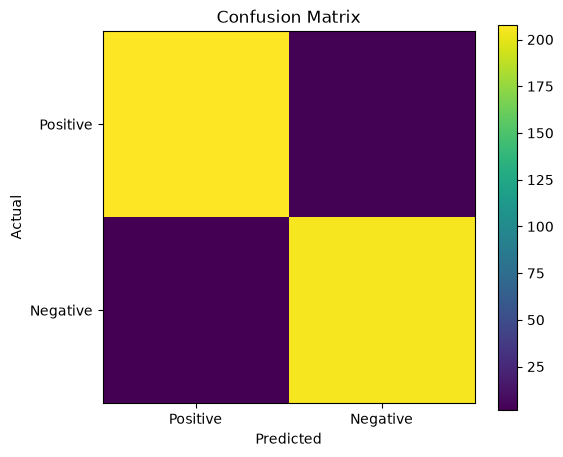

In [59]:
# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    rf_predictions
)

print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks(
    [0, 1],
    ['Positive', 'Negative']
)

plt.yticks(
    [0, 1],
    ['Positive', 'Negative']
)

plt.colorbar()

plt.show()

In [63]:
print("Best parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(rf_grid_search.best_score_)

print("\nTest accuracy:")
print(rf_test_accuracy)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best cross-validation accuracy:
0.9808293323263383

Test accuracy:
0.9880382775119617
